In [1]:
import torch
import math
import pickle
from helper_functions import encode_corpus, load_wikipedia_text, make_dataloaders
from tokenizers import Tokenizer
from transformer_lm import TransformerLM
from tqdm import tqdm  
from matplotlib import pyplot as plt

/zhome/32/4/214716/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def count_bytes_of_tokens(tokenizer, ids):
    total_bytes = 0

    for tid in ids:
        token_str = tokenizer.id_to_token(tid)
        utf8_bytes = token_str.encode("utf-8", errors="replace")
        total_bytes += len(utf8_bytes)

    return total_bytes

In [5]:
SEQ_LEN = 128
BATCH_SIZE = 512
LEARNING_RATE = 1e-4
TARGET_CHARS = 20 * 2_221_696
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizers = [
    # "bpe", # reference tokenizer
    "bytelevel"
    # "unigram"
]


text_en = load_wikipedia_text(language="en", target_chars=TARGET_CHARS)
text_ru = load_wikipedia_text(language="ru", target_chars=TARGET_CHARS)

text = text_en + text_ru

reference_tokenizer_name = "bytelevel"

Using device: cpu


In [8]:
for tokenizer_name in tokenizers:

    tokenizer = Tokenizer.from_file(f"tokenizers/{tokenizer_name}_tokenizer.json")

    vocab_size = tokenizer.get_vocab_size()

    ids = encode_corpus(tokenizer, text)

    # _, _, test_loader = make_dataloaders(ids[:SEQ_LEN*(2**10)], seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
    _, _, test_loader = make_dataloaders(ids, seq_len=SEQ_LEN, batch_size=BATCH_SIZE, stride=SEQ_LEN//2)

    model = TransformerLM(vocab_size=vocab_size, max_seq_length=SEQ_LEN).to(device)
    state_dict = torch.load(f"models/{tokenizer_name}_transformer.pth", map_location=device, weights_only=True)
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)

    criterion = torch.nn.CrossEntropyLoss()
    num_tokens = len(ids)
    num_bytes = count_bytes_of_tokens(tokenizer, ids)
    
    ref_num_tokens = None

    with torch.no_grad():
        model.eval()
        test_loss = 0.0
        count = 0
        for x, y in tqdm(test_loader, desc=f"Validation", unit="batch"):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            test_loss += loss.item()
            count += 1

        avg_test_loss = test_loss / max(count, 1)
        
        avg_test_byte_loss = avg_test_loss * (num_tokens / num_bytes)
        
    
        test_ppl = math.exp(avg_test_loss)
        
        test_byte_ppl = math.exp(avg_test_byte_loss)
        
        if ref_num_tokens is None:
            ref_num_tokens = num_tokens
        
        scaling = num_tokens / ref_num_tokens
        normalized_loss = avg_test_loss * scaling
        normalized_ppl = math.exp(normalized_loss)

        test_bpc = avg_test_loss / math.log(2)
        print(f"Results for tokenizer: {tokenizer_name}")
        print(f"loss: {avg_test_loss:.4f}, ppl: {test_ppl:.4f}, bpc: {test_bpc:.4f}, byte-ppl: {test_byte_ppl:.4f}, normalized-ppl: {normalized_ppl:.4f}")


Encoded 4689 texts into 24672487 token IDs
Vocabulary size: 16384


Validation:  35%|███▌      | 53/150 [06:45<12:21,  7.64s/batch]


KeyboardInterrupt: 

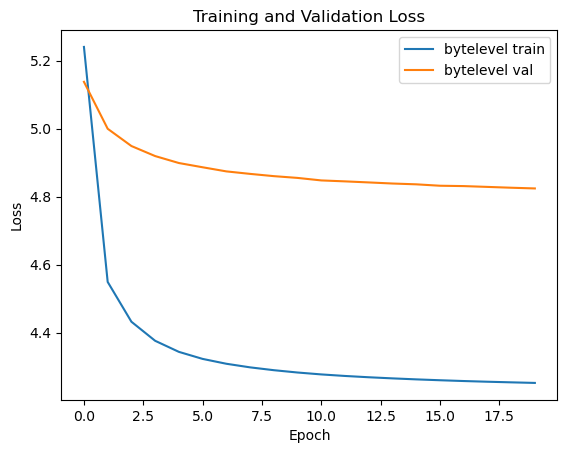

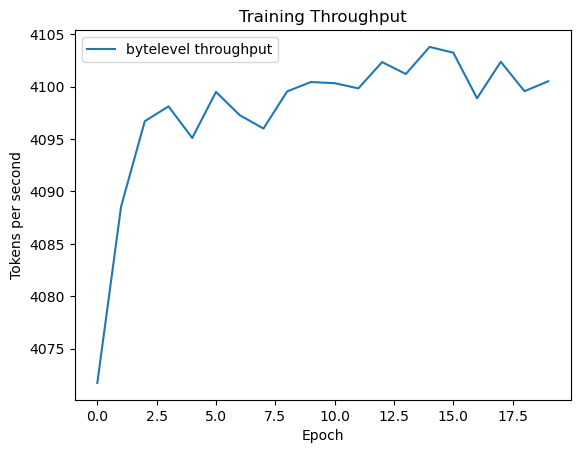

In [6]:
for tokenizer_name in tokenizers:
    history = pickle.load(open(f"history/{tokenizer_name}_training_history.pkl", "rb"))
    plt.plot(history['train_loss'], label=f"{tokenizer_name} train")
    plt.plot(history['val_loss'], label=f"{tokenizer_name} val")    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss")
    plt.show()

for tokenizer_name in tokenizers:
    plt.plot(history['throughput'], label=f"{tokenizer_name} throughput")
    plt.xlabel("Epoch")
    plt.ylabel("Tokens per second")
    plt.legend()
    plt.title("Training Throughput")
    plt.show()